In [1]:
# Cell 1 — Mount Drive & create project folders
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path("/content/drive/MyDrive/BrainMRI")
PROJECT_ROOT = DRIVE_ROOT
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
METRICS_DIR = PROJECT_ROOT / "metrics"
TEST_RESULTS_DIR = PROJECT_ROOT / "test_results"   # where final evaluation outputs will be saved

# Ensure directories exist
for p in [DRIVE_ROOT, CHECKPOINT_DIR, METRICS_DIR, TEST_RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT:", DRIVE_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("TEST_RESULTS_DIR:", TEST_RESULTS_DIR)


Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/BrainMRI
CHECKPOINT_DIR: /content/drive/MyDrive/BrainMRI/checkpoints
METRICS_DIR: /content/drive/MyDrive/BrainMRI/metrics
TEST_RESULTS_DIR: /content/drive/MyDrive/BrainMRI/test_results


In [5]:
# Cell 2 — Download dataset from Kaggle into Colab runtime
from google.colab import files
import os, shutil
from pathlib import Path

# 1) Upload kaggle.json when prompted
print("Upload kaggle.json now (use the file selector that appears).")
uploaded = files.upload()  # upload kaggle.json

# 2) move + permission
os.makedirs("/root/.kaggle", exist_ok=True)
if "kaggle.json" not in uploaded:
    raise RuntimeError("Please upload 'kaggle.json' containing your Kaggle API token.")
with open("kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 3) Download dataset (as in your original code)
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p ./dataset_tmp --force

# 4) extract to runtime folder
!unzip -o ./dataset_tmp/brain-tumor-mri-dataset.zip -d ./brainMri

# 5) define runtime DATA_ROOT
DATA_ROOT = "/content/brainMri"
print("DATA_ROOT set to:", DATA_ROOT)


Upload kaggle.json now (use the file selector that appears).


Streaming output truncated to the last 5000 lines.
  inflating: ./brainMri/Training/glioma/Tr-gl_0713.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0714.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0715.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0716.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0717.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0718.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0719.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0720.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0721.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0722.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0723.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0724.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0725.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0726.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0727.jpg  
  inflating: ./brainMri/Training/glioma/Tr-gl_0728.jpg  
  inflating: ./brainMri/Training/glio

In [6]:
# Cell 3 — Install required libs and imports
!pip -q install --upgrade pip
!pip -q install timm==1.0.9 torchmetrics==1.4.0.post0 scikit-learn==1.5.2 opencv-python-headless==4.10.0.84 einops==0.8.0

import torch, torch.nn as nn, torch.nn.functional as F
import timm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from glob import glob
import numpy as np
from tqdm.auto import tqdm
import pandas as pd
import json
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Device: cuda


In [7]:
# Cell 3 — Inspect dataset structure & print sample files
from pathlib import Path
from glob import glob
import os

DATA_ROOT = Path("/content/brainMri")
print("Exists:", DATA_ROOT.exists())

# show top-level structure
for p in sorted(DATA_ROOT.iterdir()):
    print(p.name, "->", "dir" if p.is_dir() else "file")

# expected Training & Testing folders — list them if present
for split in ["Training", "Testing"]:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        print(f"\nContents of {split_dir}:")
        for cls in sorted([d.name for d in split_dir.iterdir() if d.is_dir()]):
            cls_dir = split_dir / cls
            files = list(cls_dir.rglob("*"))
            img_files = [f for f in files if f.suffix.lower() in [".png",".jpg",".jpeg",".bmp",".tif",".tiff"]]
            print(f"  {cls:12s} | files: {len(img_files)} | sample:", img_files[:3])
    else:
        print(f"\nWarning: {split_dir} does not exist. Check dataset extraction.")


Exists: True
Testing -> dir
Training -> dir

Contents of /content/brainMri/Training:
  glioma       | files: 1321 | sample: [PosixPath('/content/brainMri/Training/glioma/Tr-gl_0208.jpg'), PosixPath('/content/brainMri/Training/glioma/Tr-gl_0802.jpg'), PosixPath('/content/brainMri/Training/glioma/Tr-gl_0865.jpg')]
  meningioma   | files: 1339 | sample: [PosixPath('/content/brainMri/Training/meningioma/Tr-me_0043.jpg'), PosixPath('/content/brainMri/Training/meningioma/Tr-me_0217.jpg'), PosixPath('/content/brainMri/Training/meningioma/Tr-me_0950.jpg')]
  notumor      | files: 1595 | sample: [PosixPath('/content/brainMri/Training/notumor/Tr-no_1588.jpg'), PosixPath('/content/brainMri/Training/notumor/Tr-no_0412.jpg'), PosixPath('/content/brainMri/Training/notumor/Tr-no_0733.jpg')]
  pituitary    | files: 1457 | sample: [PosixPath('/content/brainMri/Training/pituitary/Tr-pi_0607.jpg'), PosixPath('/content/brainMri/Training/pituitary/Tr-pi_0563.jpg'), PosixPath('/content/brainMri/Training/pit

In [8]:
from pathlib import Path

CHECKPOINT_DIR = Path("/content/drive/MyDrive/BrainMRI/checkpoints")

print("📁 CHECKPOINT_DIR =", CHECKPOINT_DIR)
print("Exists:", CHECKPOINT_DIR.exists())

print("\n🔽 Files in checkpoints:")
for f in sorted(CHECKPOINT_DIR.glob("*")):
    print(" -", f.name)


📁 CHECKPOINT_DIR = /content/drive/MyDrive/BrainMRI/checkpoints
Exists: True

🔽 Files in checkpoints:
 - ConvNeXtTiny_runD_best.pth
 - DenseNet121_runB_best.pth
 - EfficientNetB0_runC_best.pth
 - ResNet50_runA_best.pth
 - ViTSmall16_runE_best.pth


In [9]:
from pathlib import Path

METRICS_DIR = Path("/content/drive/MyDrive/BrainMRI/metrics")

print("📁 METRICS_DIR =", METRICS_DIR)
print("Exists:", METRICS_DIR.exists())

print("\n🔽 Files in metrics:")
for f in sorted(METRICS_DIR.glob("*")):
    print(" -", f.name)


📁 METRICS_DIR = /content/drive/MyDrive/BrainMRI/metrics
Exists: True

🔽 Files in metrics:
 - ConvNeXtTiny_runD_history.csv
 - DenseNet121_runB_history.csv
 - EfficientNetB0_runC_history.csv
 - ResNet50_runA_history.csv
 - ViTSmall16_runE_history.csv


In [10]:
# ---- Run this cell BEFORE evaluate_best(...) ----
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from glob import glob
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1) Basic globals (ensure DEVICE exists)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

# 2) Class names + num classes (needed for model creation)
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASS_NAMES)
print("NUM_CLASSES =", NUM_CLASSES)

# 3) Test transforms + Dataset + DataLoader
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
DATA_ROOT = "/content/brainMri"   # path you used earlier

base_test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class BrainMRIDataset(Dataset):
    def __init__(self, root=DATA_ROOT, split="test"):
        self.samples = []
        actual = "Training" if split == "train" else "Testing"
        for idx, cls in enumerate(CLASS_NAMES):
            cls_dir = Path(root) / actual / cls
            if not cls_dir.exists():
                continue
            files = sorted(glob(str(cls_dir/"**/*"), recursive=True))
            for p in files:
                if p.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff")):
                    self.samples.append((p, idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        img = base_test_tf(img)
        return img, label, path

# create test loader
test_ds = BrainMRIDataset(root=DATA_ROOT, split="test")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
print("Test samples:", len(test_ds))
if len(test_ds)>0:
    print("Example sample:", test_ds.samples[0])

# 4) Re-define FocalCE and evaluate (same as your training env)
class FocalCE(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        with torch.no_grad():
            pt = F.softmax(logits, dim=-1).gather(1, targets.view(-1,1)).clamp_(1e-6,1-1e-6).squeeze()
        focal = ((1-pt)**self.gamma).mean()
        return ce + 0.5 * focal

@torch.no_grad()
def evaluate(model, loader, loss_fn, epoch=0):
    model.eval()
    total, n = 0.0, 0
    y_true, y_pred, y_prob = [], [], []
    pbar = tqdm(loader, desc=f"Eval", leave=True)
    for x, y, _ in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss = loss_fn(logits, y)
        probs = F.softmax(logits, dim=-1)

        total += loss.item() * x.size(0)
        n += x.size(0)

        y_true.extend(y.cpu().tolist())
        y_pred.extend(probs.argmax(1).cpu().tolist())
        y_prob.append(probs.cpu().numpy())

        pbar.set_postfix(loss=f"{(total/max(n,1)):.4f}")

    if len(y_prob):
        y_prob = np.concatenate(y_prob, axis=0)
    else:
        y_prob = np.zeros((0, NUM_CLASSES))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = float(accuracy_score(y_true, y_pred)) if y_true.size else float('nan')
    f1 = float(f1_score(y_true, y_pred, average='macro')) if y_true.size else float('nan')

    try:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        auc = float(roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr'))
    except Exception:
        auc = float('nan')

    return total / max(n,1), acc, f1, auc, (y_true, y_pred, y_prob)

print("Setup done — now run your evaluate_best(...) cell.")


DEVICE = cuda
NUM_CLASSES = 4
Test samples: 1311
Example sample: ('/content/brainMri/Testing/glioma/Te-glTr_0000.jpg', 0)
Setup done — now run your evaluate_best(...) cell.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [11]:
# --- Correct mapping between your names and actual checkpoint names ---
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

MODEL_MAP = {
    "ResNet50": ("resnet50", "ResNet50_runA_best.pth"),
    "DenseNet121": ("densenet121", "DenseNet121_runB_best.pth"),
    "EfficientNetB0": ("efficientnet_b0", "EfficientNetB0_runC_best.pth"),
    "ConvNeXtTiny": ("convnext_tiny", "ConvNeXtTiny_runD_best.pth"),
    "ViTSmall16": ("vit_small_patch16_224", "ViTSmall16_runE_best.pth"),
}

def evaluate_best(model_name):
    if model_name not in MODEL_MAP:
        print("❌ Unknown model:", model_name)
        return

    timm_key, ckpt_file = MODEL_MAP[model_name]
    ckpt_path = CHECKPOINT_DIR / ckpt_file

    print(f"\nLoading {model_name} from {ckpt_file}")

    # Create model
    model = timm.create_model(timm_key, pretrained=False, num_classes=NUM_CLASSES, in_chans=3).to(DEVICE)

    # Load checkpoint (safe for your files)
    state = torch.load(ckpt_path, map_location="cpu")

    # Strip module. prefix if present
    new_state = {}
    for k,v in state.items():
        if k.startswith("module."):
            new_state[k[7:]] = v
        else:
            new_state[k] = v

    model.load_state_dict(new_state, strict=True)
    model.eval()

    # Evaluate
    val_loss, val_acc, val_f1, val_auc, _ = evaluate(
        model, test_loader, FocalCE(), 0
    )

    print(f"✔ {model_name} Best Results")
    print(f"   Accuracy = {val_acc:.4f}")
    print(f"   F1 Score = {val_f1:.4f}")
    print(f"   AUC      = {val_auc:.4f}")


In [12]:
evaluate_best("ResNet50")
evaluate_best("DenseNet121")
evaluate_best("EfficientNetB0")
evaluate_best("ConvNeXtTiny")
evaluate_best("ViTSmall16")



Loading ResNet50 from ResNet50_runA_best.pth


Eval:   0%|          | 0/82 [00:00<?, ?it/s]

✔ ResNet50 Best Results
   Accuracy = 0.9947
   F1 Score = 0.9946
   AUC      = 0.9999

Loading DenseNet121 from DenseNet121_runB_best.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Eval:   0%|          | 0/82 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/82 [00:00<?, ?it/s]

✔ ConvNeXtTiny Best Results
   Accuracy = 0.9977
   F1 Score = 0.9975
   AUC      = 1.0000

Loading ViTSmall16 from ViTSmall16_runE_best.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Eval:   0%|          | 0/82 [00:00<?, ?it/s]

✔ ViTSmall16 Best Results
   Accuracy = 0.9825
   F1 Score = 0.9815
   AUC      = 0.9993


In [13]:
# Cell A — load histories and test results (if present)
import pandas as pd
from pathlib import Path
import json

METRICS_DIR = Path("/content/drive/MyDrive/BrainMRI/metrics")
TEST_RESULTS_DIR = Path("/content/drive/MyDrive/BrainMRI/test_results")

hist_files = {
    "ResNet50_runA": METRICS_DIR / "ResNet50_runA_history.csv",
    "DenseNet121_runB": METRICS_DIR / "DenseNet121_runB_history.csv",
    "EfficientNetB0_runC": METRICS_DIR / "EfficientNetB0_runC_history.csv",
    "ConvNeXtTiny_runD": METRICS_DIR / "ConvNeXtTiny_runD_history.csv",
    "ViTSmall16_runE": METRICS_DIR / "ViTSmall16_runE_history.csv"
}

histories = {}
for name, path in hist_files.items():
    if path.exists():
        try:
            histories[name] = pd.read_csv(path)
            print("Loaded history:", path.name, "| epochs:", len(histories[name]))
        except Exception as e:
            print("Could not read", path, ":", e)
    else:
        print("Missing history CSV:", path)

# Optional: load test_results JSONs if you ran evaluation
test_results = {}
if TEST_RESULTS_DIR.exists():
    for name in hist_files.keys():
        jpath = TEST_RESULTS_DIR / f"{name}_eval.json"
        if jpath.exists():
            try:
                with open(jpath, "r") as f:
                    test_results[name] = json.load(f)
                print("Loaded test results:", jpath.name)
            except Exception as e:
                print("Failed to load", jpath, ":", e)
        else:
            print("No test JSON for", name, "| expected:", jpath.name)
else:
    print("TEST_RESULTS_DIR not found:", TEST_RESULTS_DIR)


Loaded history: ResNet50_runA_history.csv | epochs: 20
Loaded history: DenseNet121_runB_history.csv | epochs: 19
Loaded history: EfficientNetB0_runC_history.csv | epochs: 20
Loaded history: ConvNeXtTiny_runD_history.csv | epochs: 20
Loaded history: ViTSmall16_runE_history.csv | epochs: 10
No test JSON for ResNet50_runA | expected: ResNet50_runA_eval.json
No test JSON for DenseNet121_runB | expected: DenseNet121_runB_eval.json
No test JSON for EfficientNetB0_runC | expected: EfficientNetB0_runC_eval.json
No test JSON for ConvNeXtTiny_runD | expected: ConvNeXtTiny_runD_eval.json
No test JSON for ViTSmall16_runE | expected: ViTSmall16_runE_eval.json


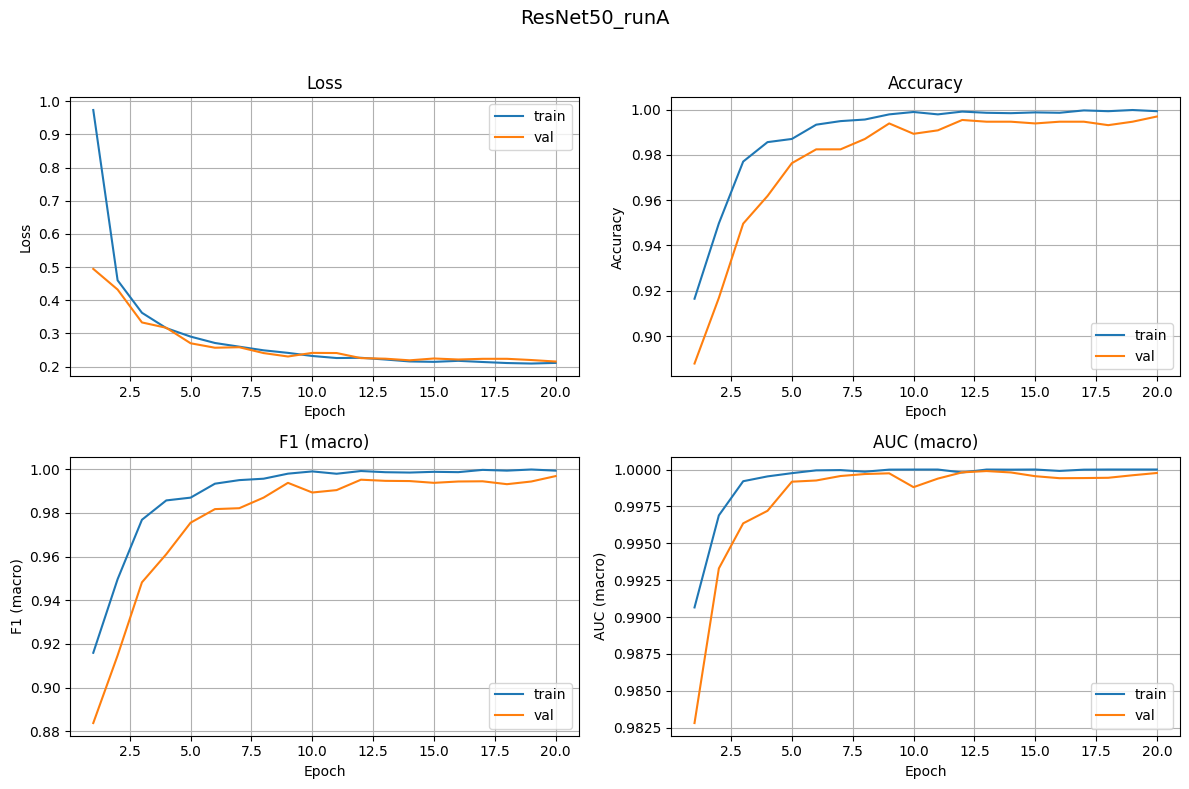

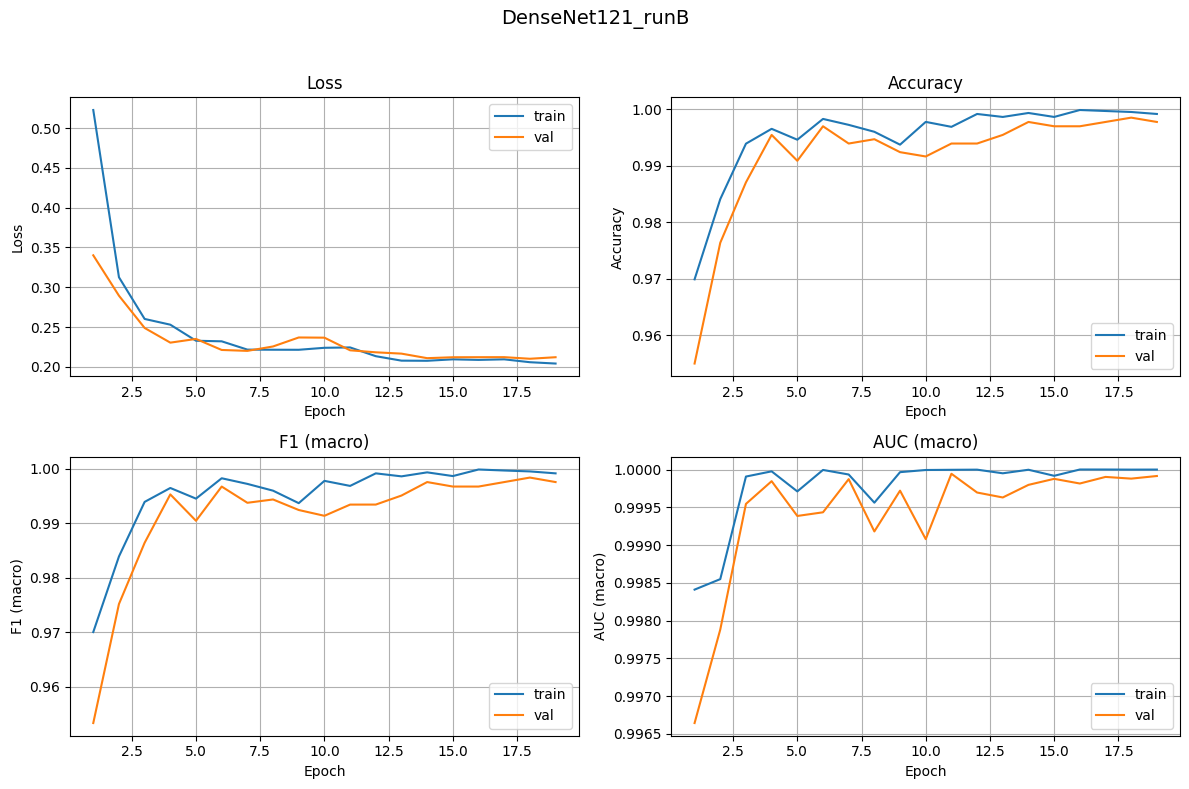

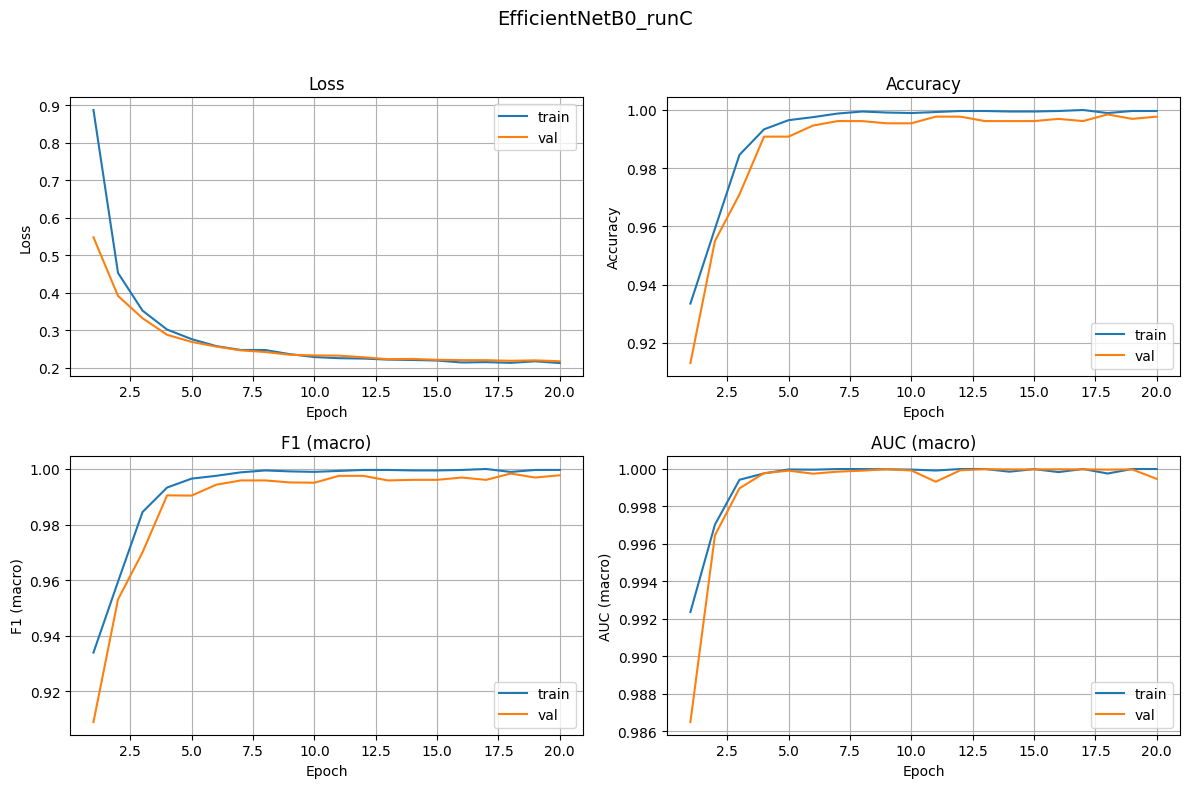

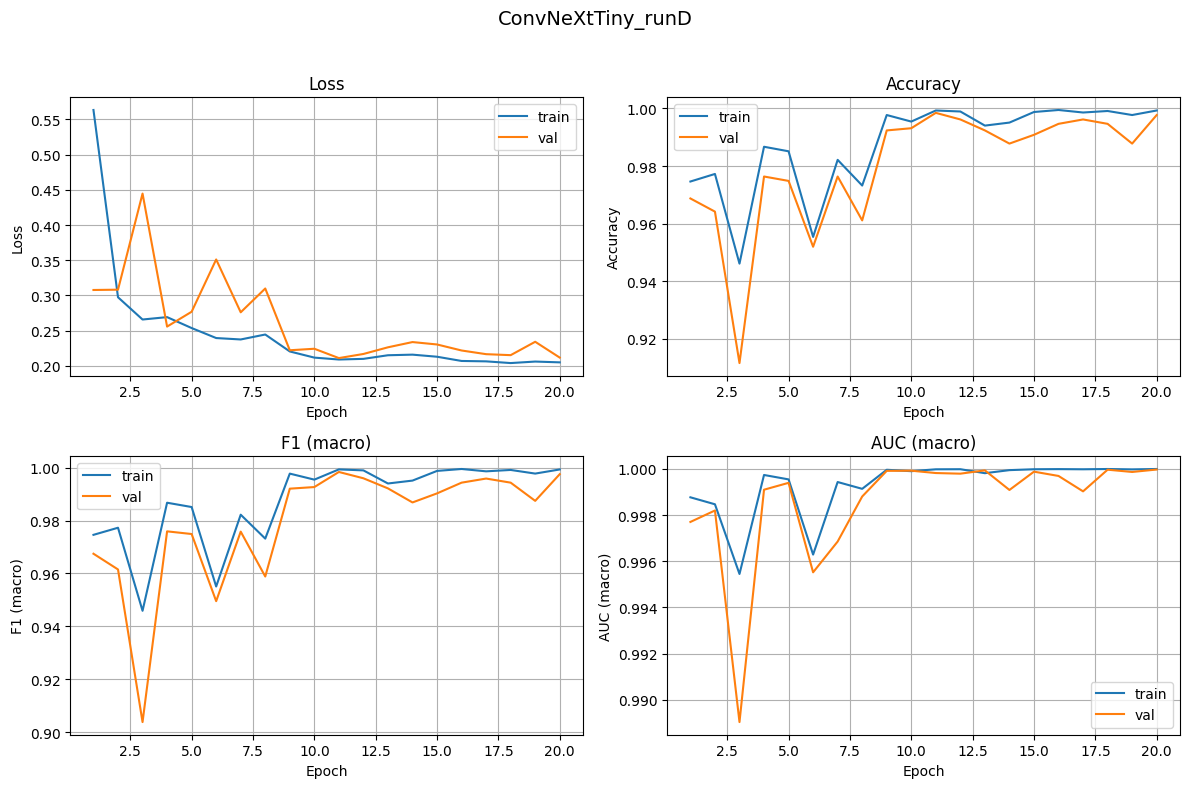

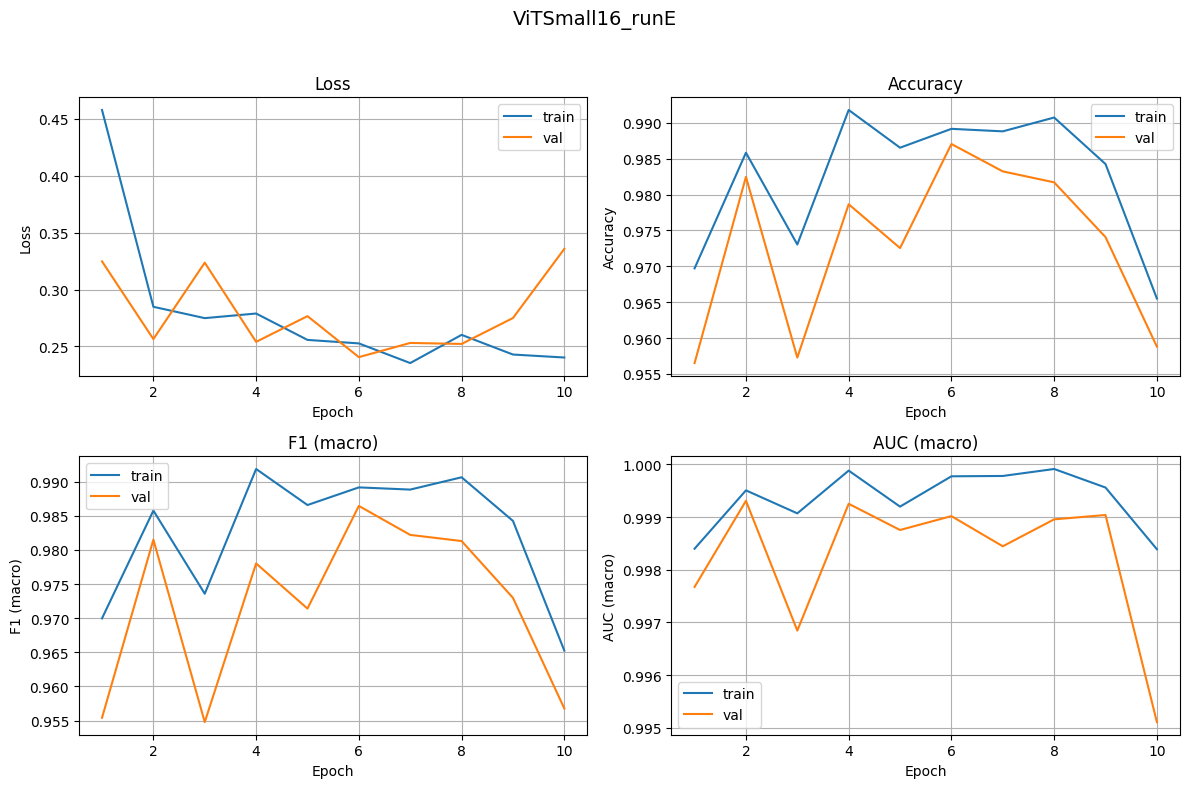

In [14]:
# Cell B — per-model 4-panel plots (train+val curves)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,6)

metrics_to_plot = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc",  "val_acc",  "Accuracy"),
    ("train_f1",   "val_f1",   "F1 (macro)"),
    ("train_auc",  "val_auc",  "AUC (macro)")
]

for run_name, df in histories.items():
    if df is None or df.empty:
        continue
    fig, axes = plt.subplots(2,2, figsize=(12,8))
    axes = axes.flatten()
    epochs = range(1, len(df)+1)
    for i, (tcol, vcol, title) in enumerate(metrics_to_plot):
        ax = axes[i]
        plotted = False
        if tcol in df.columns:
            ax.plot(epochs, df[tcol].values, label="train")
            plotted = True
        if vcol in df.columns:
            ax.plot(epochs, df[vcol].values, label="val")
            plotted = True
        if not plotted:
            ax.text(0.5,0.5,"No data", ha="center", va="center")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True)
    fig.suptitle(run_name, fontsize=14)
    fig.tight_layout(rect=[0,0,1,0.96])
    plt.show()


Available test samples per class:
  0 glioma: 300 examples
  1 meningioma: 306 examples
  2 notumor: 405 examples
  3 pituitary: 300 examples
Selected 8 samples (2 per class requested).

Model: ResNet50_runA | checkpoint: ResNet50_runA_best.pth | exists: True


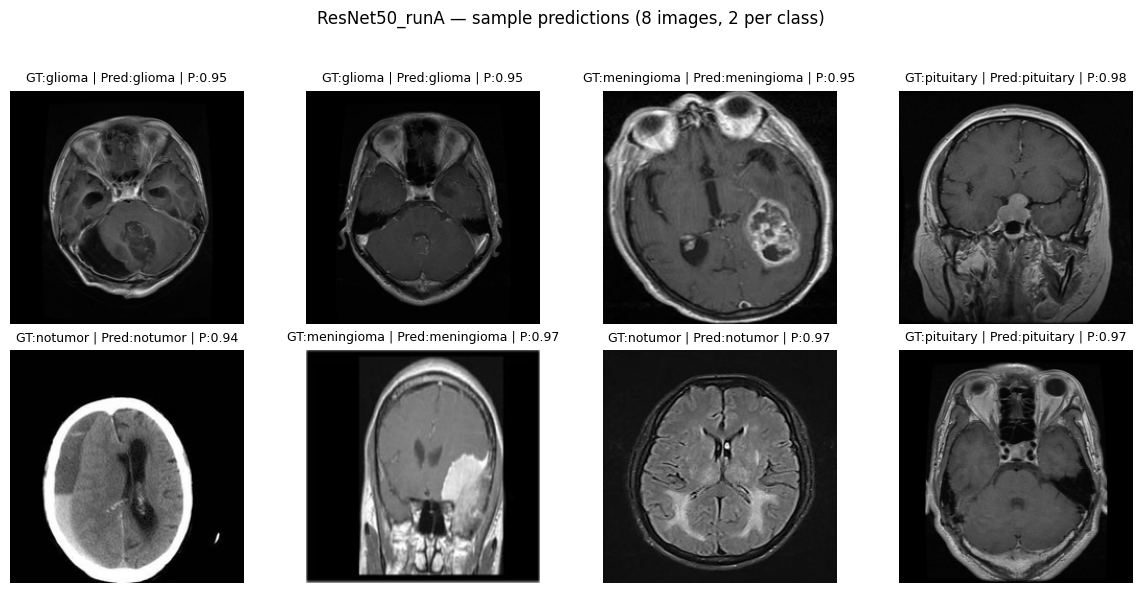


Model: DenseNet121_runB | checkpoint: DenseNet121_runB_best.pth | exists: True


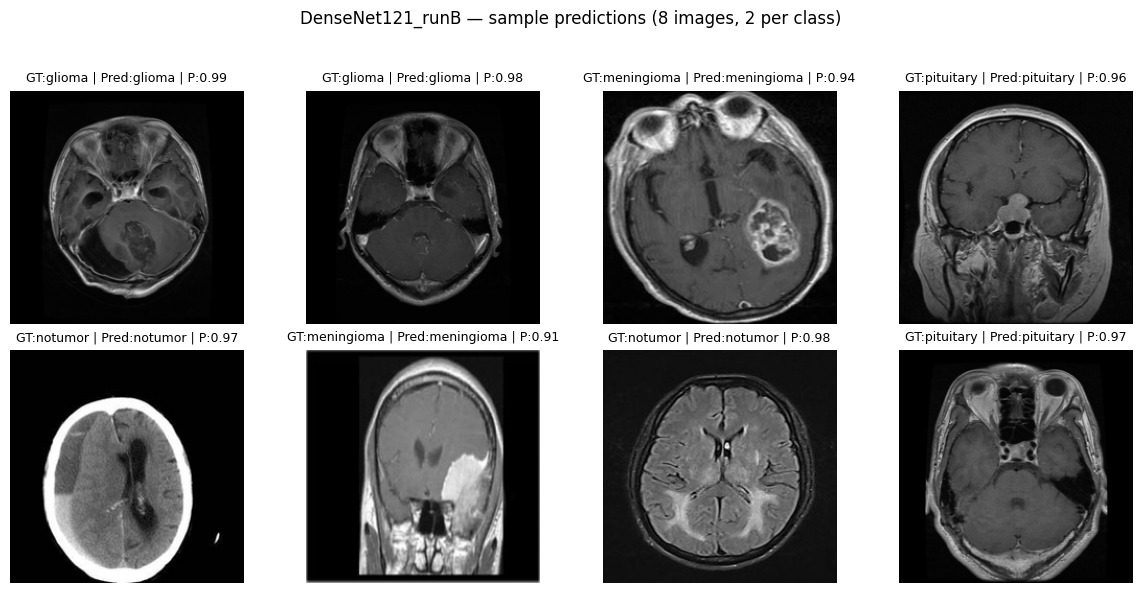


Model: EfficientNetB0_runC | checkpoint: EfficientNetB0_runC_best.pth | exists: True


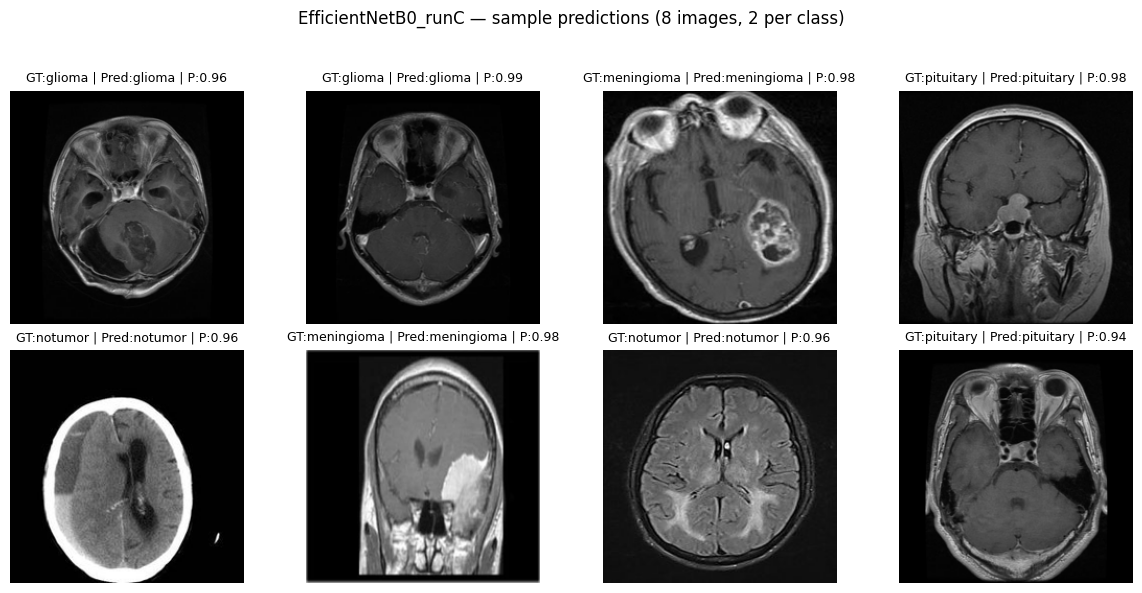


Model: ConvNeXtTiny_runD | checkpoint: ConvNeXtTiny_runD_best.pth | exists: True


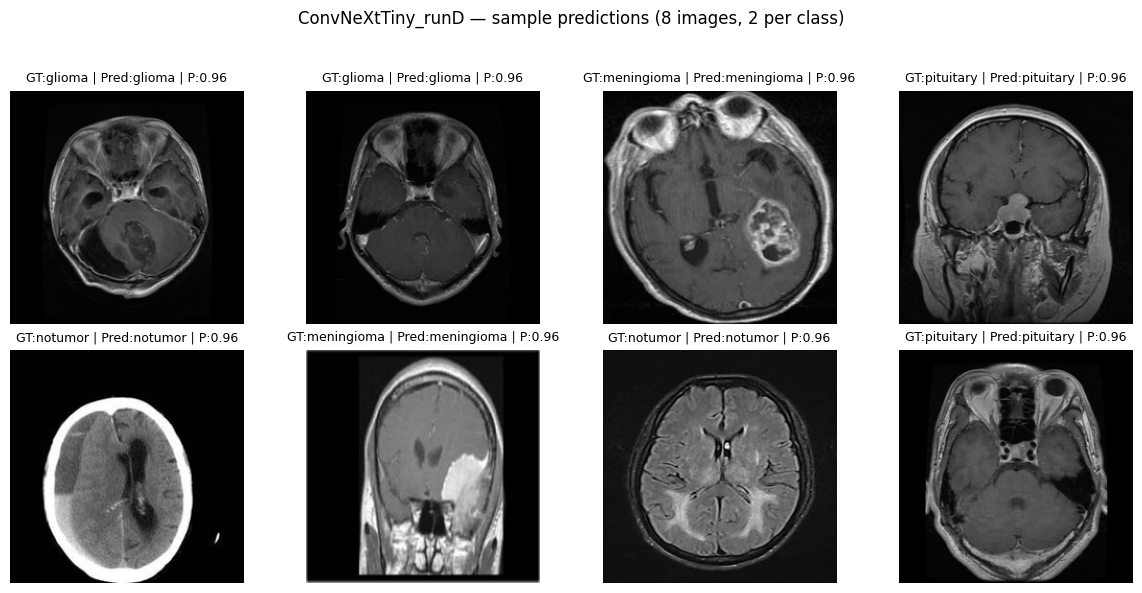


Model: ViTSmall16_runE | checkpoint: ViTSmall16_runE_best.pth | exists: True


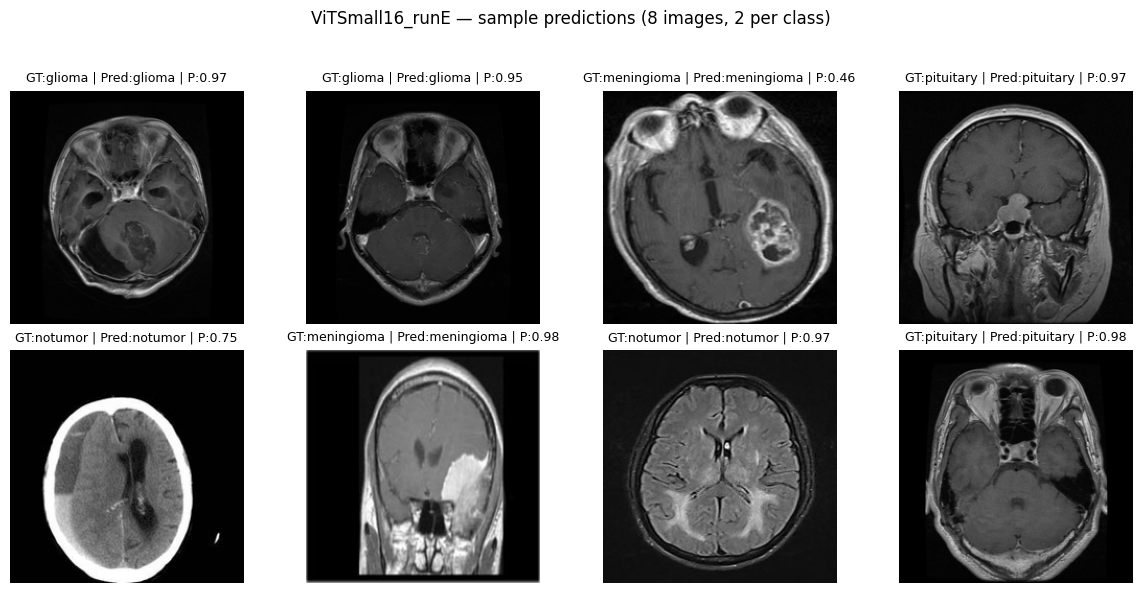

In [15]:
# Preview balanced samples: per_class samples for each class, then run all 5 models
import timm, torch, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from pathlib import Path

# Settings
per_class = 2      # number of samples per class (set to 2 to get 2x4 = 8 images)
cols = 4           # columns to display in grid
models = {
    "ResNet50_runA": "resnet50",
    "DenseNet121_runB": "densenet121",
    "EfficientNetB0_runC": "efficientnet_b0",
    "ConvNeXtTiny_runD": "convnext_tiny",
    "ViTSmall16_runE": "vit_small_patch16_224"
}
CHECKPOINT_DIR = TEST_RESULTS_DIR.parent / "checkpoints"

# Build index per class from test_ds.samples (list of (path,label))
class_index = defaultdict(list)
for path, lbl in test_ds.samples:
    class_index[lbl].append(path)

# For debug: print available counts
print("Available test samples per class:")
for i, cname in enumerate(CLASS_NAMES):
    print(f"  {i} {cname}: {len(class_index[i])} examples")

# Select up to per_class samples per class (take first ones). If you want random pick, set shuffle=True below.
shuffle_within_class = False
selected = []
for cls_idx in range(len(CLASS_NAMES)):
    files = class_index[cls_idx]
    if not files:
        continue
    if shuffle_within_class:
        rng = np.random.default_rng(42 + cls_idx)
        files = list(rng.choice(files, size=min(per_class, len(files)), replace=False))
    else:
        files = files[:per_class]
    selected.extend([(p, cls_idx) for p in files])

if not selected:
    raise RuntimeError("No test samples found. Ensure test_ds is loaded and points to Testing folder.")

# Shuffle overall order for mixed grid
np.random.seed(123)
np.random.shuffle(selected)
sample_count = len(selected)
print(f"Selected {sample_count} samples ({per_class} per class requested).")

# For each model, load and show predictions for the same selected samples
for run_name, timm_key in models.items():
    ckpt_path = CHECKPOINT_DIR / f"{run_name}_best.pth"
    print("\n" + "="*60)
    print("Model:", run_name, "| checkpoint:", ckpt_path.name, "| exists:", ckpt_path.exists())
    if not ckpt_path.exists():
        print("  -> Checkpoint missing. Skipping", run_name)
        continue

    # instantiate model and load weights robustly
    model = timm.create_model(timm_key, pretrained=False, num_classes=len(CLASS_NAMES), in_chans=3)
    state = torch.load(ckpt_path, map_location="cpu")
    if isinstance(state, dict) and ("model_state_dict" in state or "state_dict" in state):
        sd = state.get("model_state_dict", state.get("state_dict", state))
    else:
        sd = state
    sd_clean = {}
    for k,v in sd.items():
        if k.startswith("module."):
            sd_clean[k[7:]] = v
        else:
            sd_clean[k] = v
    try:
        model.load_state_dict(sd_clean, strict=False)
    except Exception as e:
        print("  -> Warning loading state_dict:", e)
    model = model.to(DEVICE)
    model.eval()

    # Collect images, predictions
    imgs = []
    titles = []
    with torch.no_grad():
        for p, lbl in selected:
            img = Image.open(p).convert("RGB")
            img_t = base_test_tf(img).unsqueeze(0).to(DEVICE)
            logits = model(img_t)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            pred = int(probs.argmax())
            prob_pred = probs[pred]
            title = f"GT:{CLASS_NAMES[lbl]} | Pred:{CLASS_NAMES[pred]} | P:{prob_pred:.2f}"
            imgs.append(np.array(img.resize((224,224))))
            titles.append(title)

    # plot grid for this model
    rows = (len(imgs) + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        plt.imshow(im)
        plt.title(titles[i], fontsize=9)
        plt.axis("off")
    plt.suptitle(f"{run_name} — sample predictions ({sample_count} images, {per_class} per class)")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


In [16]:
# ======================================================================
#  SAVE ALL PLOTS + ALL TEST RESULTS INTO TEST_RESULTS_DIR
# ======================================================================

import matplotlib.pyplot as plt
from pathlib import Path
import json
import numpy as np
import pandas as pd

SAVE_DIR = Path("/content/drive/MyDrive/BrainMRI/test_results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Saving everything into:", SAVE_DIR)


# ======================================================================
# 1) SAVE TRAINING PLOTS (Loss, Acc, F1, AUC) FOR EACH MODEL
# ======================================================================

metrics_to_plot = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc",  "val_acc",  "Accuracy"),
    ("train_f1",   "val_f1",   "F1 Score (Macro)"),
    ("train_auc",  "val_auc",  "AUC (Macro)")
]

for run_name, df in histories.items():
    fig, axes = plt.subplots(2,2, figsize=(12,8))
    axes = axes.flatten()
    epochs = range(1, len(df)+1)

    for i, (tcol, vcol, title) in enumerate(metrics_to_plot):
        ax = axes[i]
        if tcol in df and vcol in df:
            ax.plot(epochs, df[tcol], label="Train")
            ax.plot(epochs, df[vcol], label="Val")
            ax.set_title(title)
            ax.legend()
            ax.grid()
        else:
            ax.text(0.5,0.5,"No Data", ha="center")
    fig.suptitle(run_name)
    out_path = SAVE_DIR / f"{run_name}_training_curves.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print("✔ Saved training plot:", out_path)


# ======================================================================
# 2) SAVE COMBINED VALIDATION CURVES (Loss, Acc, F1, AUC)
# ======================================================================

compare_metrics = [
    ("val_loss", "Validation Loss"),
    ("val_acc",  "Validation Accuracy"),
    ("val_f1",   "Validation F1 Macro"),
    ("val_auc",  "Validation AUC Macro")
]

for key, title in compare_metrics:
    plt.figure(figsize=(10,5))
    for run_name, df in histories.items():
        if key in df:
            plt.plot(df[key], label=run_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.legend()
    plt.grid()
    out_path = SAVE_DIR / f"comparison_{key}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print("✔ Saved:", out_path)


# ======================================================================
# 3) SAVE SAMPLE PREDICTION GRID IMAGES FOR EACH MODEL
# ======================================================================

import timm
from PIL import Image
import torch
import numpy as np

for run_name, timm_key in models.items():

    ckpt_path = CHECKPOINT_DIR / f"{run_name}_best.pth"
    if not ckpt_path.exists():
        print("Skipping missing model:", run_name)
        continue

    # Reload model
    model = timm.create_model(timm_key, pretrained=False, num_classes=len(CLASS_NAMES), in_chans=3)
    state = torch.load(ckpt_path, map_location="cpu")
    sd = state.get("state_dict", state.get("model_state_dict", state)) if isinstance(state, dict) else state
    clean_sd = { (k[7:] if k.startswith("module.") else k):v for k,v in sd.items() }
    model.load_state_dict(clean_sd, strict=False)
    model = model.to(DEVICE)
    model.eval()

    # Generate grid figure again
    rows = (sample_count + cols - 1) // cols
    fig = plt.figure(figsize=(cols*3, rows*3))

    imgs = []
    titles = []

    with torch.no_grad():
        for p, lbl in selected:
            img = Image.open(p).convert("RGB")
            img_t = base_test_tf(img).unsqueeze(0).to(DEVICE)
            probs = torch.softmax(model(img_t), dim=-1).cpu().numpy()[0]
            pred = int(probs.argmax())
            prob_pred = probs[pred]

            imgs.append(np.array(img.resize((224,224))))
            titles.append(f"GT:{CLASS_NAMES[lbl]} | Pred:{CLASS_NAMES[pred]} | P:{prob_pred:.2f}")

    for i, im in enumerate(imgs):
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(im)
        ax.set_title(titles[i], fontsize=8)
        ax.axis("off")

    fig.suptitle(f"{run_name} Predictions ({sample_count} samples)")
    out_path = SAVE_DIR / f"{run_name}_predictions.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print("✔ Saved prediction grid:", out_path)


# ======================================================================
# 4) SAVE TEST RESULTS JSON (if test_results dict exists)
# ======================================================================

if len(test_results) > 0:
    for run_name, content in test_results.items():
        out_json = SAVE_DIR / f"{run_name}_results.json"
        with open(out_json, "w") as f:
            json.dump(content, f, indent=2)
        print("✔ Saved test_result JSON:", out_json)


# ======================================================================
# 5) SAVE CONFUSION MATRICES AND CLASSIFICATION REPORTS (if available)
# ======================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for run_name, content in test_results.items():
    cm = content.get("confusion_matrix")
    cr = content.get("classification_report")

    # Save Confusion Matrix
    if cm is not None:
        cm = np.array(cm)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        fig, ax = plt.subplots(figsize=(5,4))
        disp.plot(ax=ax, values_format="d")
        plt.title(run_name + " — Confusion Matrix")
        out_cm = SAVE_DIR / f"{run_name}_confusion_matrix.png"
        plt.savefig(out_cm, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print("✔ Saved confusion matrix:", out_cm)

    # Save Classification Report
    if cr is not None:
        df = pd.DataFrame(cr).transpose()
        out_txt = SAVE_DIR / f"{run_name}_classification_report.txt"
        with open(out_txt, "w") as f:
            f.write(df.to_string())
        print("✔ Saved classification report:", out_txt)


print("\n🎉 ALL PLOTS + RESULTS SAVED SUCCESSFULLY!")


Saving everything into: /content/drive/MyDrive/BrainMRI/test_results
✔ Saved training plot: /content/drive/MyDrive/BrainMRI/test_results/ResNet50_runA_training_curves.png
✔ Saved training plot: /content/drive/MyDrive/BrainMRI/test_results/DenseNet121_runB_training_curves.png
✔ Saved training plot: /content/drive/MyDrive/BrainMRI/test_results/EfficientNetB0_runC_training_curves.png
✔ Saved training plot: /content/drive/MyDrive/BrainMRI/test_results/ConvNeXtTiny_runD_training_curves.png
✔ Saved training plot: /content/drive/MyDrive/BrainMRI/test_results/ViTSmall16_runE_training_curves.png
✔ Saved: /content/drive/MyDrive/BrainMRI/test_results/comparison_val_loss.png
✔ Saved: /content/drive/MyDrive/BrainMRI/test_results/comparison_val_acc.png
✔ Saved: /content/drive/MyDrive/BrainMRI/test_results/comparison_val_f1.png
✔ Saved: /content/drive/MyDrive/BrainMRI/test_results/comparison_val_auc.png
✔ Saved prediction grid: /content/drive/MyDrive/BrainMRI/test_results/ResNet50_runA_predictions.pn

In [17]:
!pip install thop


In [18]:
# === BENCHMARK ALL MODELS (PRINT + SAVE CSV) ===

import time
import pandas as pd
import torch
import numpy as np
from pathlib import Path
from thop import profile
import timm
import torch.nn as nn

# ---------- PATHS ----------
RESULTS_DIR = Path("/content/drive/MyDrive/BrainMRI/test_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path("/content/drive/MyDrive/BrainMRI/checkpoints")

# ---------- MODEL CONFIG ----------
MODEL_CONFIGS = {
    "ResNet50":        "resnet50",
    "DenseNet121":     "densenet121",
    "EfficientNetB0":  "efficientnet_b0",
    "ConvNeXtTiny":    "convnext_tiny",
    "ViTSmall16":      "vit_small_patch16_224"
}

CHECKPOINT_FILES = {
    "ResNet50":        "ResNet50_runA_best.pth",
    "DenseNet121":     "DenseNet121_runB_best.pth",
    "EfficientNetB0":  "EfficientNetB0_runC_best.pth",
    "ConvNeXtTiny":    "ConvNeXtTiny_runD_best.pth",
    "ViTSmall16":      "ViTSmall16_runE_best.pth"
}

benchmark_rows = []

IMG_SIZE = 224
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

for model_name, timm_name in MODEL_CONFIGS.items():
    print(f"\n🔍 Benchmarking {model_name}")

    # Load model
    model = timm.create_model(timm_name, pretrained=False, num_classes=NUM_CLASSES, in_chans=3)
    ckpt_path = CHECKPOINT_DIR / CHECKPOINT_FILES[model_name]

    state = torch.load(ckpt_path, map_location="cpu")
    clean_state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(clean_state, strict=False)

    model = model.to(DEVICE)
    model.eval()

    # -------- Parameters --------
    params_m = sum(p.numel() for p in model.parameters()) / 1e6

    # -------- GFLOPs --------
    with torch.no_grad():
        flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
    gflops = flops / 1e9

    # -------- Inference Time --------
    timings = []
    with torch.no_grad():
        for x, _, _ in test_loader:
            x = x.to(DEVICE)
            start = time.time()
            _ = model(x)
            end = time.time()
            timings.append((end - start) / x.size(0))

    inference_ms = np.mean(timings) * 1000

    # -------- Metrics --------
    loss, acc, f1, auc, _ = evaluate(model, test_loader, nn.CrossEntropyLoss())

    benchmark_rows.append({
        "Model": model_name,
        "Loss": round(loss, 4),
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4),
        "AUC": round(auc, 4),
        "Parameters (M)": round(params_m, 2),
        "GFLOPs": round(gflops, 2),
        "Inference Time (ms/img)": round(inference_ms, 2)
    })

# -------- SAVE + PRINT --------
df = pd.DataFrame(benchmark_rows)
csv_path = RESULTS_DIR / "model_benchmark.csv"
df.to_csv(csv_path, index=False)

print("\n📊 FINAL MODEL BENCHMARK TABLE")
print(df)
print("\n💾 CSV saved at:", csv_path)



🔍 Benchmarking ResNet50


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Eval:   0%|          | 0/82 [00:00<?, ?it/s]


🔍 Benchmarking DenseNet121


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Eval:   0%|          | 0/82 [00:00<?, ?it/s]


🔍 Benchmarking ViTSmall16


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Eval:   0%|          | 0/82 [00:00<?, ?it/s]


📊 FINAL MODEL BENCHMARK TABLE
            Model    Loss  Accuracy  F1 Score     AUC  Parameters (M)  GFLOPs  \
0        ResNet50  0.0563    0.9947    0.9946  0.9999           23.52    4.13   
1     DenseNet121  0.0564    0.9939    0.9934  0.9999            6.96    2.83   
2  EfficientNetB0  0.0446    0.9962    0.9959  1.0000            4.01    0.38   
3    ConvNeXtTiny  0.0474    0.9977    0.9975  1.0000           27.82    4.45   
4      ViTSmall16  0.0838    0.9825    0.9815  0.9993           21.67    4.24   

   Inference Time (ms/img)  
0                     2.20  
1                     3.87  
2                     3.15  
3                     1.72  
4                     1.67  

💾 CSV saved at: /content/drive/MyDrive/BrainMRI/test_results/model_benchmark.csv
